In [1]:
""" Plot the pore water cation balance """
import os
import xarray as xr
from glob import glob
import pandas as pd
import numpy as np
from shared_read_HBR import *
from matplotlib import rcParams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap
import itertools as it

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

# soil layer depths in ELM
zsoi = np.array([0.0071, 0.0279, 0.0623, 0.1189, 0.2122, 0.3661, 0.6198, 1.0380, 1.7276, 2.8646])
zisoi = np.array([0, 0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 1.3828, 2.2961, 
                  3.8019])
dzsoi = np.array([0.0175, 0.0276, 0.0455, 0.0750, 0.1236, 0.2038, 0.3360, 0.5539, 0.9133, 1.5058])

# major cation list
cations = ['Ca2+','Mg2+','Na+','K+','Al3+']

# minerals list
minerals_name = ['Wollastonite_CaSiO3', 'Forsterite_Mg2SiO4', 'Albite_NaAlSi3O8', 
                 'Anorthite_CaAl2Si2O8', 'Epidote_Ca2FeAl2(SiO4)3(OH)', 'Calcite_CaCO3',
                 'Labradorite_Ca0.6Na0.4Al1.6Si2.4O8', 'Augite_Ca0.9Mg0.9Na0.1Al0.4Fe0.2Si1.9O6',
                 'Kfeldspar_KAlSi3O8', 'Enstatite_MgSiO3']
mineral_list = [2, 7, 8, 9]

# list of NetCDF file names generated by ELM
date_prefix = '20250427'
region = 'conus'
start = 1992 # the year right before application starts
end = 2012 # 20 years after
case_suffix = 'ICB20TRCNPRDCTCBC_3yearerw'

if '1850CN' in case_suffix:
    tvec = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1YS')
else:
    tvec = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1YS')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
case_name = f'{date_prefix}_{region}_{case_suffix}'
file_list = [os.path.join(os.environ['E3SM_ROOT'], 'output', case_name, 'run', 
                          f'{case_name}.elm.h1.{year:04d}-01-01-00000.nc') \
             for year in range(start, end + 1)]

# path to save the graphs
path_out = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'plot_conus', case_name)
if not os.path.exists(path_out):
    os.mkdir(os.path.join(path_out))

# 1. Cation sources and sinks
 - background weathering influx 
 - primary cation flux
 - CEC cation flux
 - secondary cation flux
 - cation_infl_vr
 - cation_leached_vr
 - ~~cation_runoff_vr~~ (this is zero because we assume no surface mixing)
 - change in cation storage

Summarize to alkalinity using cation valence, for the base cations (Ca,Na,Mg,K)

Look at the whole soil column

In [13]:
def sum_to_depth(np_array, depth = None):
    """ helper function to sum up the second layer to selected depth 
        note the conversion is from g/m3 to g/m2
    """
    if depth is None:
        # all depth
        return np.sum(np_array[:,:len(dzsoi),:,:] * dzsoi.reshape(1,-1,1,1), 
                      axis = 1, keepdims=False)
    else:
        # partial depth may occur
        nlayers = np.where(zisoi >= depth)[0][0]
        weight = dzsoi[:nlayers]
        weight[-1] = depth - zisoi[nlayers-1]

        return np.sum(np_array[:, :nlayers, :, :] * weight.reshape(1,-1,1,1), 
                      axis = 1, keepdims=False)


def sum_to_alkalinity(da):
    """ helper function to sum up the base cations to a total alkalinity """

    # convert from weight to mol; doesn't matter how much mol
    mol_valence = da[:,0,:,:]*2 / 40 + da[:,1,:,:].values*2 / 24 + \
          da[:,2,:,:].values / 23 + da[:,3,:,:].values / 39

    # convert to weight C basis
    return mol_valence * 12

In [3]:
hr = xr.open_mfdataset(file_list)

lon = hr['lon'].values
lat = hr['lat'].values

## 1.1 Cation sources

/tmp/ipykernel_168005/2504529547.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


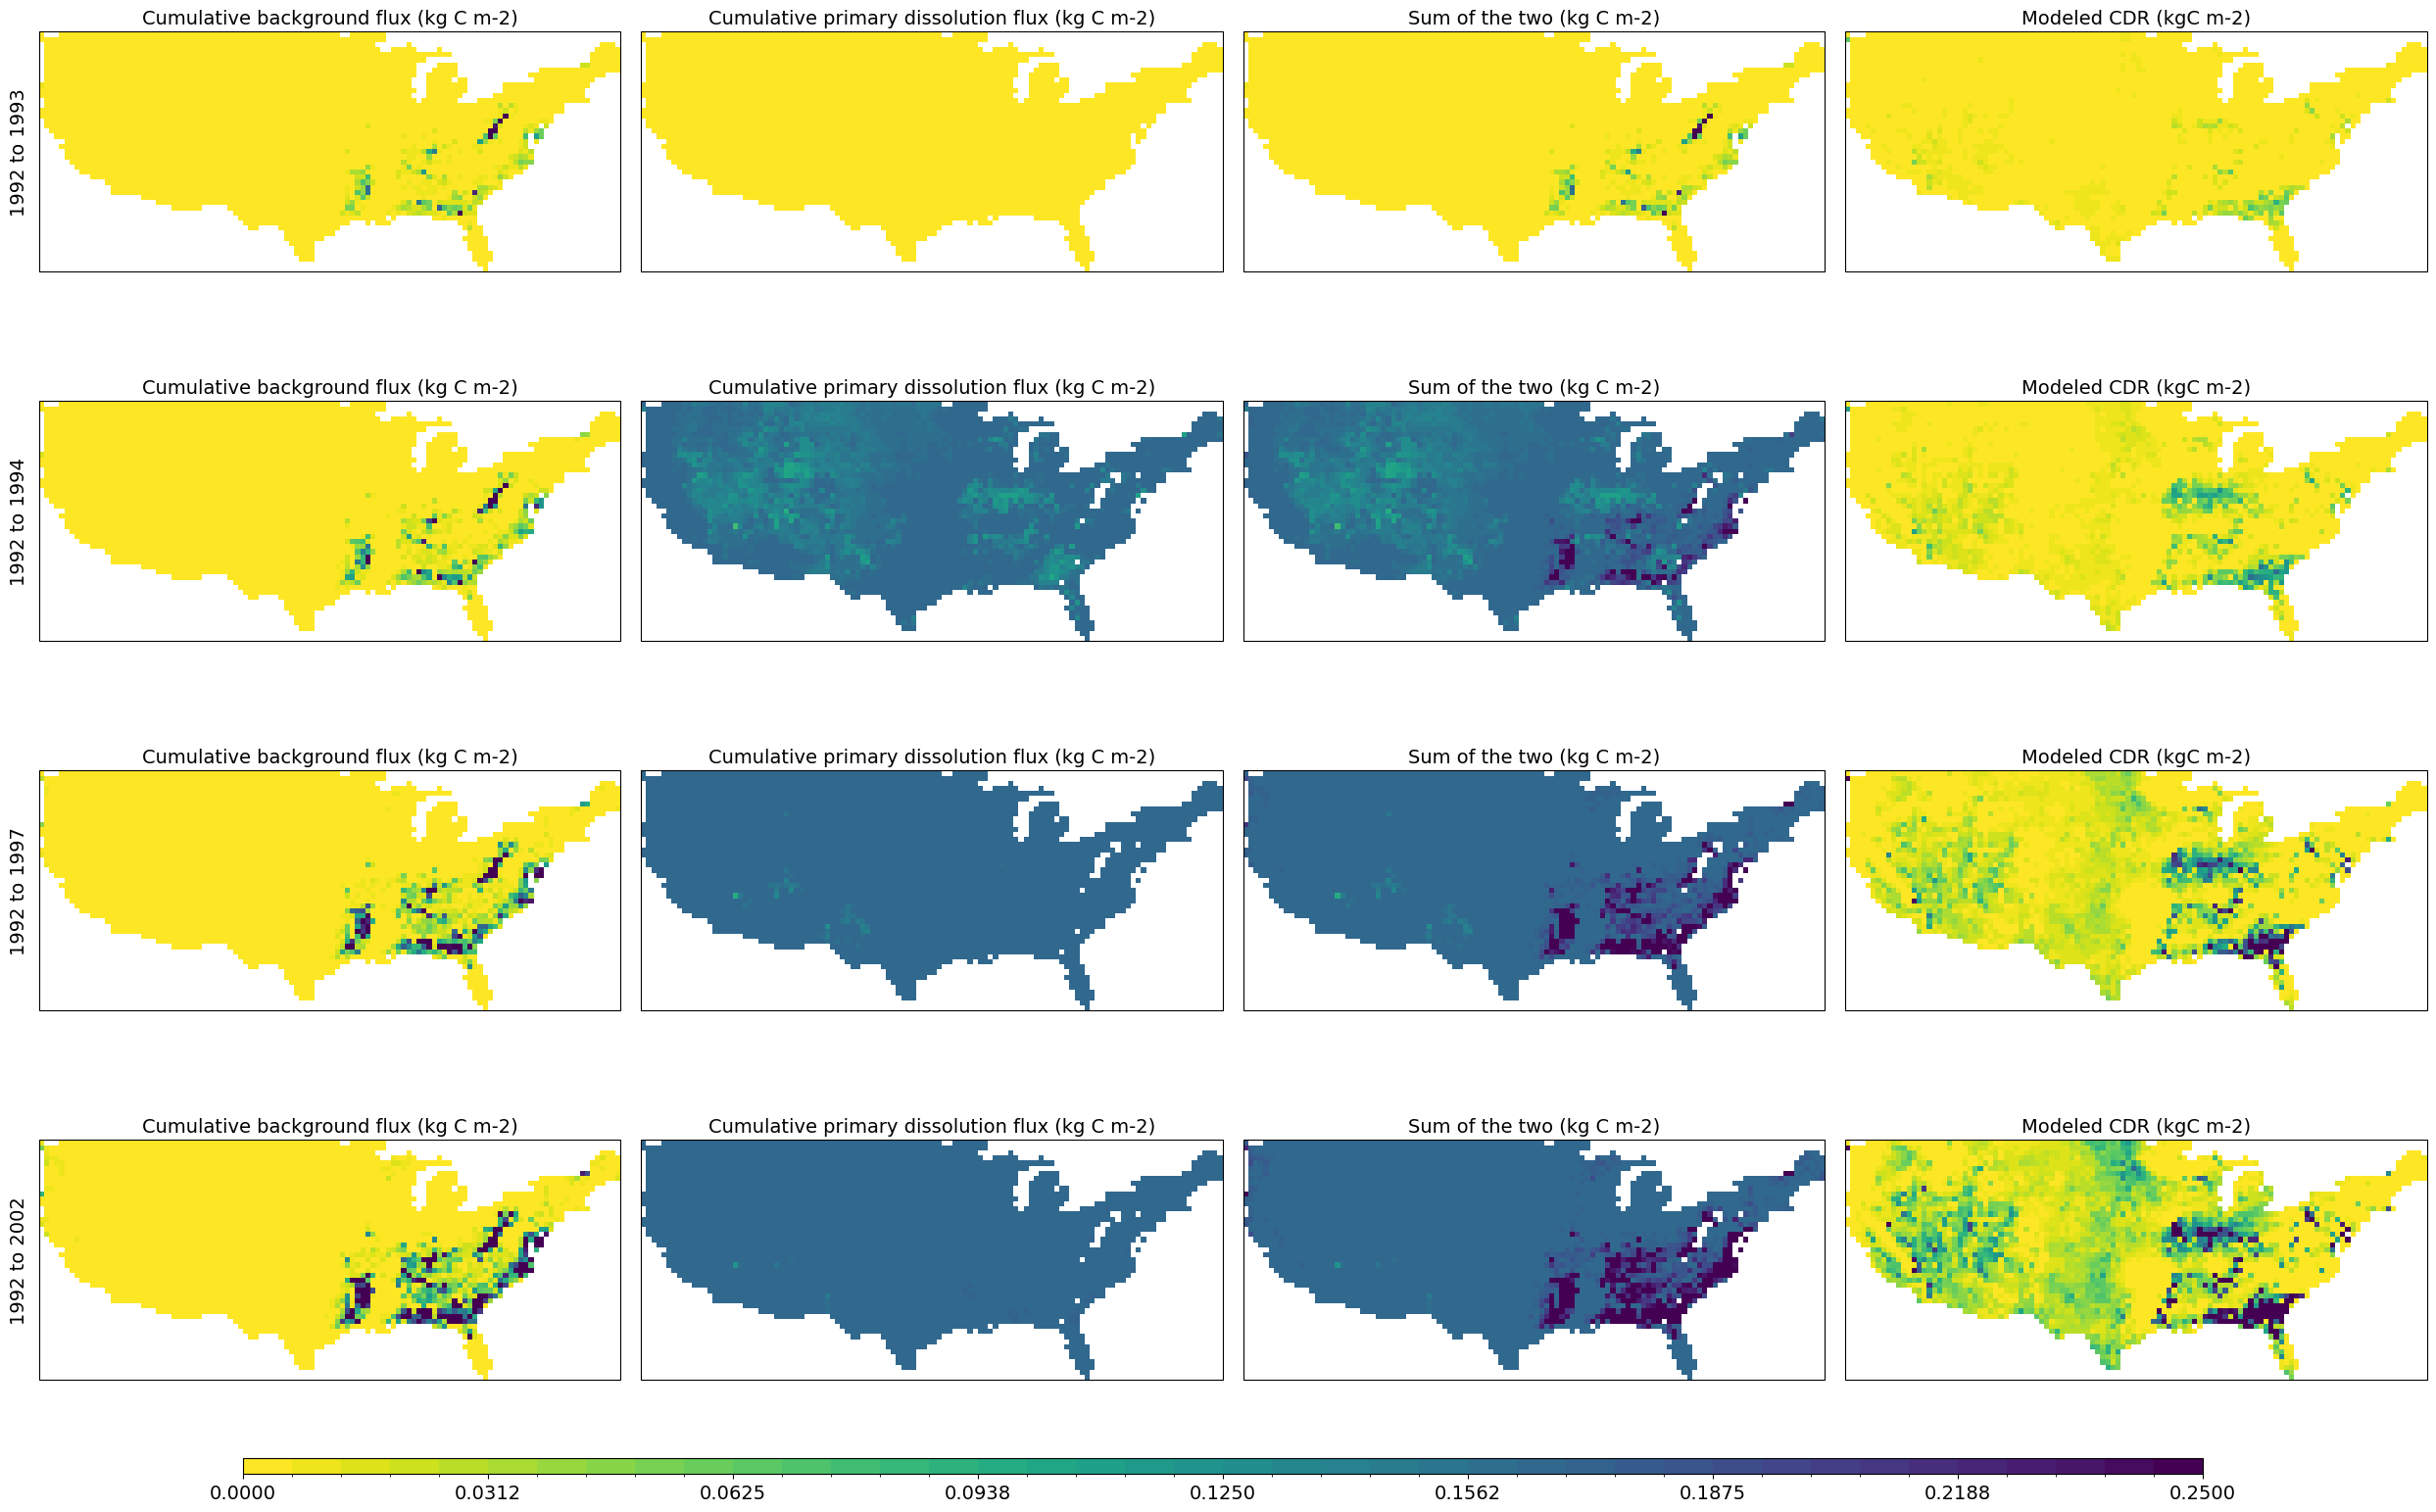

In [4]:
# g m-2 s-1 => kg m-2 year-1
background_flux = (hr['background_flux']*86400/1000
                   ).resample(time='1Y').sum(skipna=False).cumsum(axis=0, skipna=False)
primary_flux = (hr['primary_cation_flux']*86400/1000
                ).resample(time='1Y').sum(skipna=False).cumsum(axis=0, skipna=False)
# gC m-2 s-1 => kgC m-2 year-1
cdr = (hr['r_sequestration']*86400/1000
       ).resample(time='1Y').sum(skipna=False).cumsum(axis=0, skipna=False)


# plot the two influxes & compare to CDR
background_alk = sum_to_alkalinity(background_flux)
primary_alk = sum_to_alkalinity(primary_flux)

# Use the same norm for all plots
norm = BoundaryNorm(np.linspace(0, 0.25, 41), ncolors = 256)

fig, axes = plt.subplots(4, 4, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (25, 16))
for i, (name, data_var) in enumerate(zip(['Cumulative background flux (kg C m-2)', 
                                          'Cumulative primary dissolution flux (kg C m-2)',
                                          'Sum of the two (kg C m-2)',
                                          'Modeled CDR (kgC m-2)'], 
                                         [background_alk, primary_alk, 
                                          background_alk + primary_alk, cdr])):
    for j,year in enumerate([1,2,5,10]):
        ax = axes[j,i]
        cf = ax.pcolormesh(lon, lat, data_var[year-1,:,:], norm = norm, cmap = 'viridis_r')
        ax.set_title(name)
        if i == 0:
            ax.text(-0.05, 0.5, f'{start} to {start+year}', rotation = 90, va = 'center',
                    transform = ax.transAxes)
cax = fig.add_axes([0.1, 0.01, 0.8, 0.01])
plt.colorbar(cf, cax = cax, orientation = 'horizontal')
plt.tight_layout()

## 1.2 Cation sinks

In [5]:
cec_flux = xr.DataArray(
    np.full([end-start+1, len(cations), len(lat), len(lon)], np.nan),
    dims = ['time', 'cations', 'lat', 'lon'],
    coords = {'time': background_flux['time'], 
              'cations': background_flux['cations'], 
              'lat': hr['lat'], 'lon': hr['lon']}
)

# g m-2 s-1 => kg m-2 year-1
# defined positive when going into pore water
for icat in range(len(cations)):
        temp = (hr[f'cec_cation_flux_vr_{icat+1}']*86400/1000
                ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)
        temp = sum_to_depth(temp.values)

        temp2 = (hr[f'cec_cation_flux2_vr_{icat+1}']*86400/1000
                ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)
        temp2 = sum_to_depth(temp2.values)

        cec_flux[:,icat, :, :] = temp + temp2

# g m-2 s-1 => kg m-2 year-1
secondary_flux = (hr['secondary_cation_flux']*86400/1000
                  ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)

infl_flux = xr.DataArray(
    np.full([end-start+1, len(cations), len(lat), len(lon)], np.nan),
    dims = ['time', 'cations', 'lat', 'lon'],
    coords = {'time': background_flux['time'], 
              'cations': background_flux['cations'], 
              'lat': hr['lat'], 'lon': hr['lon']}
)

# g m-2 s-1 => kg m-2 year-1
# defined positive when going into pore water
for icat in range(len(cations)):
        temp = (hr[f'cation_infl_vr_{icat+1}']*86400/1000
                ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)
        temp = sum_to_depth(temp.values)

        temp2 = (hr[f'cation_infl_vr_{icat+1}']*86400/1000
                ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)
        temp2 = sum_to_depth(temp2.values)

        infl_flux[:,icat, :, :] = temp + temp2

leach_flux = (hr['cation_leached']*86400/1000
              ).resample(time='1Y').sum(skipna=False).cumsum(axis=0,skipna=False)

cec_alk = sum_to_alkalinity(cec_flux)
secondary_alk = sum_to_alkalinity(secondary_flux)
infl_alk = sum_to_alkalinity(infl_flux)
leach_alk = sum_to_alkalinity(leach_flux)

/tmp/ipykernel_168005/1061227780.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  negative = cm.get_cmap('viridis', 256)
/tmp/ipykernel_168005/1061227780.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  positive = cm.get_cmap('Reds', 256)
/tmp/ipykernel_168005/1061227780.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


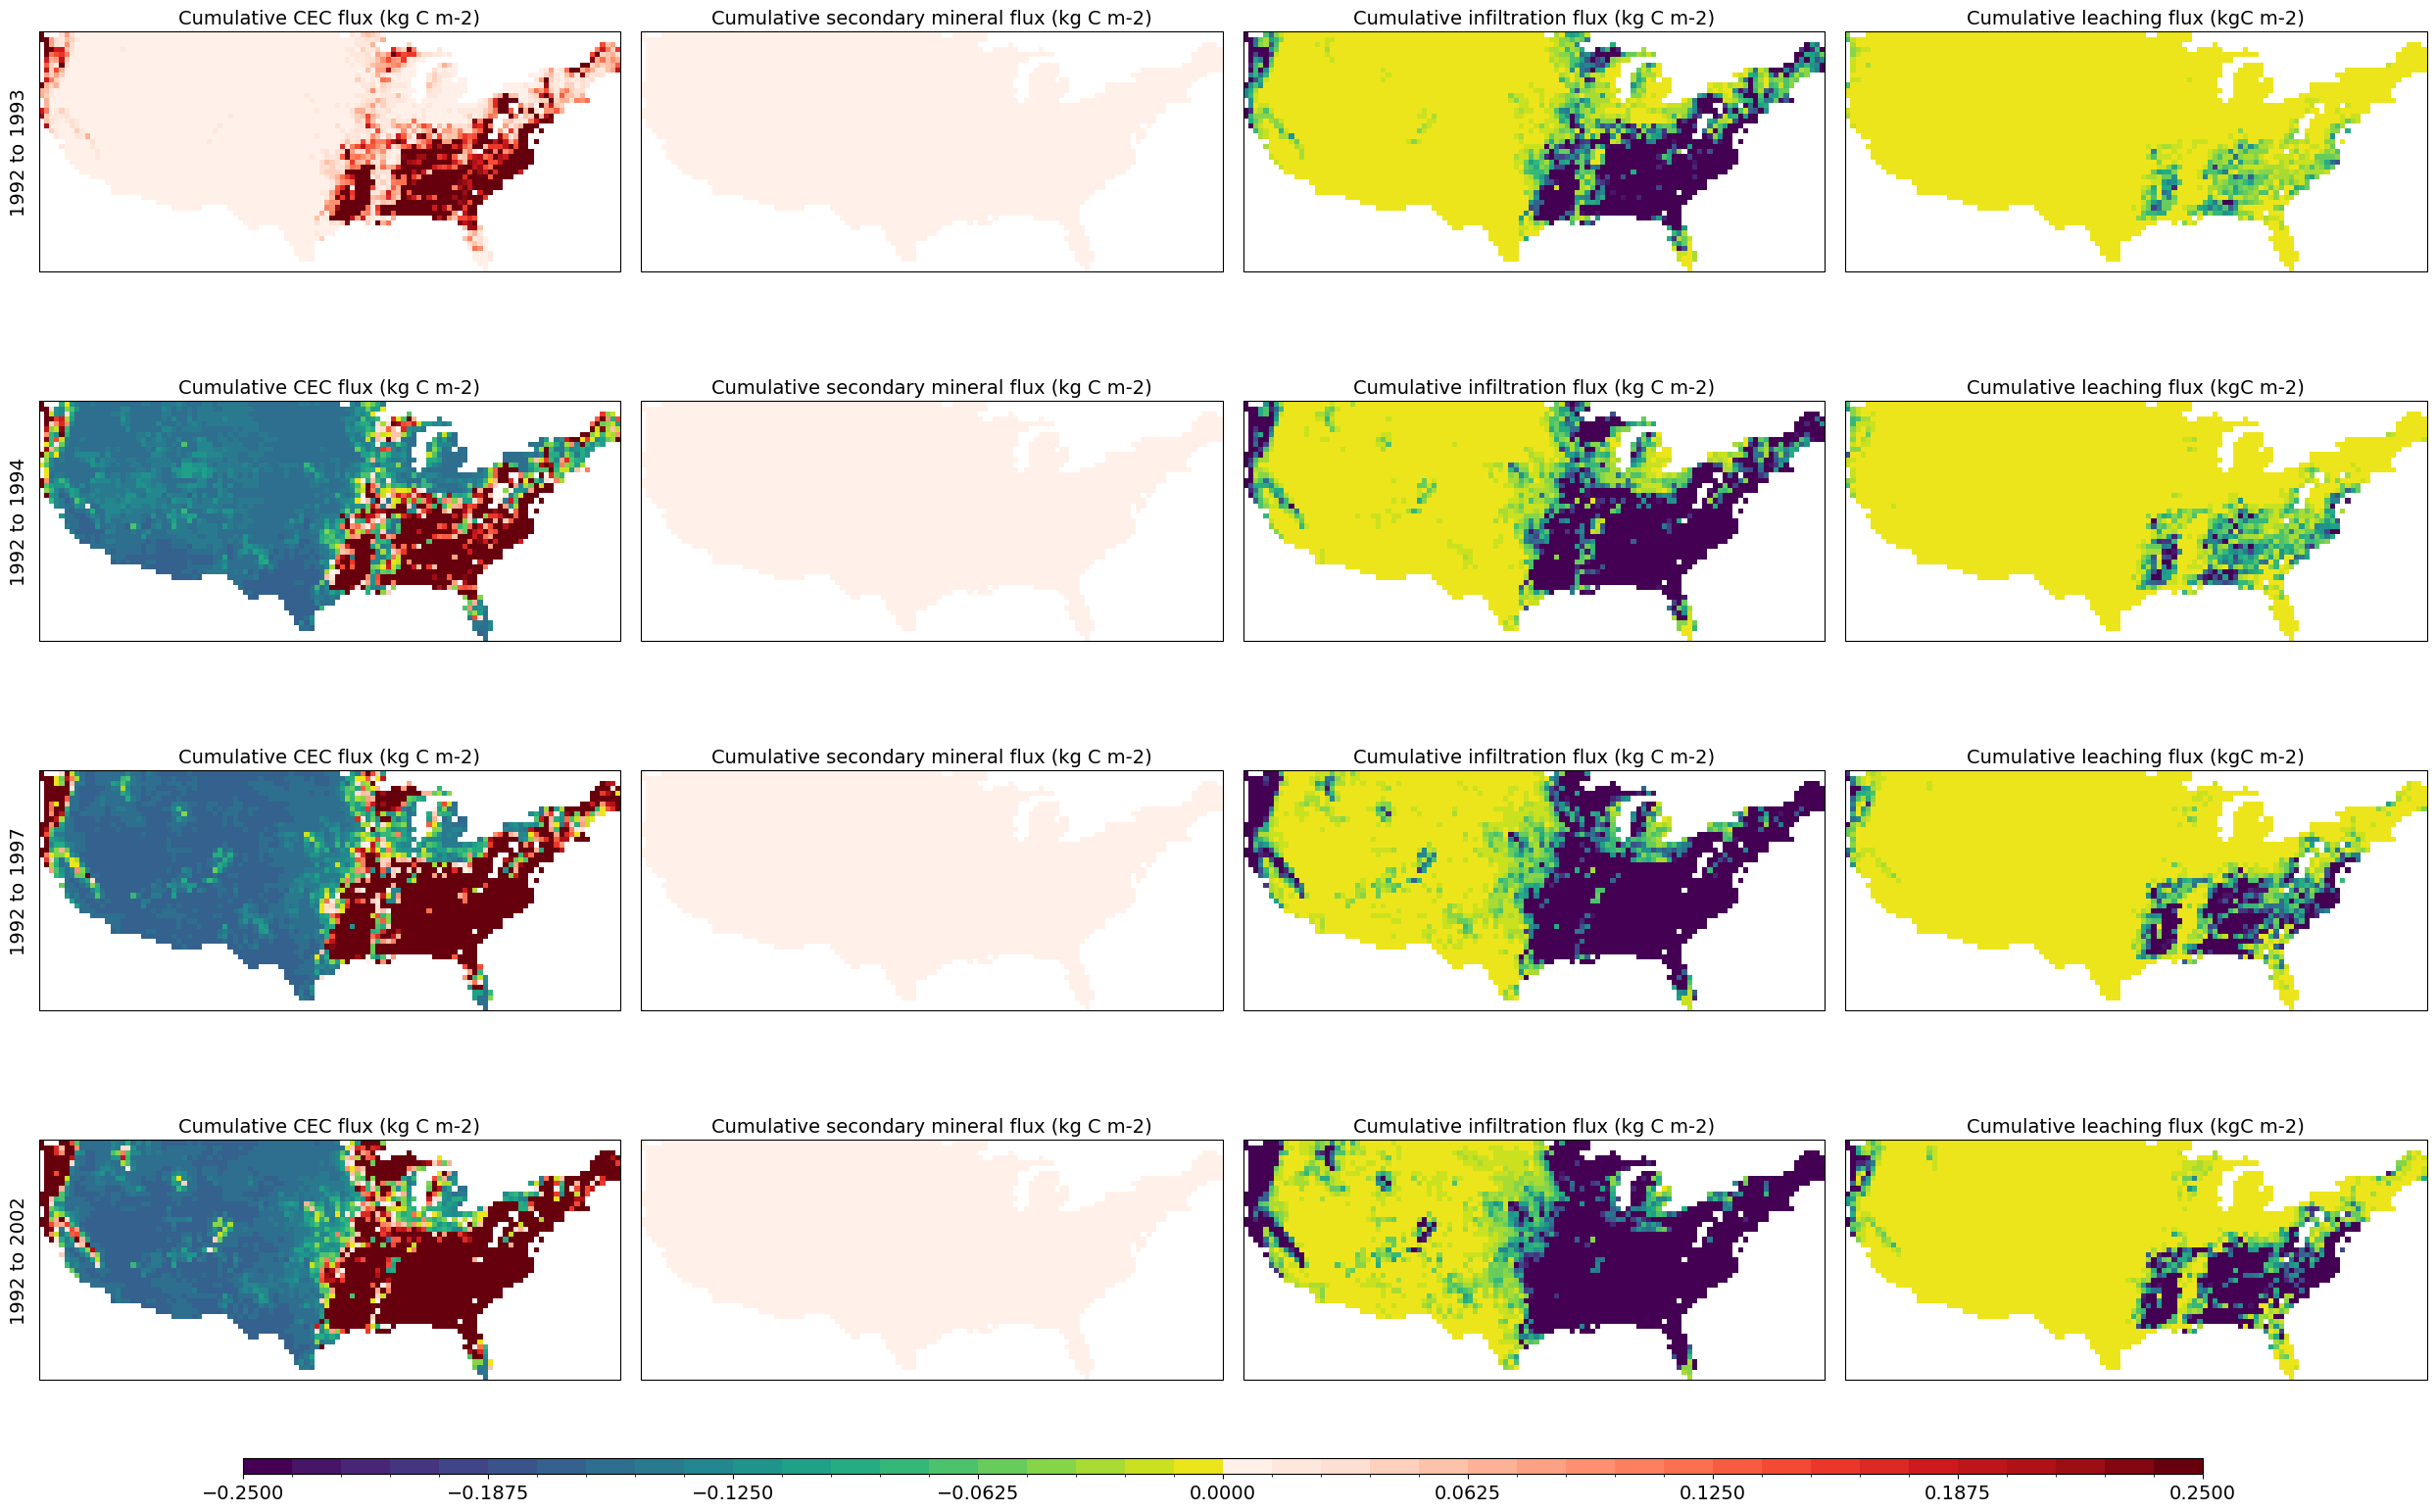

In [6]:
norm = BoundaryNorm(np.linspace(-0.25, 0.25, 41), ncolors = 256*2)

negative = cm.get_cmap('viridis', 256)
positive = cm.get_cmap('Reds', 256)

# Stack them to build a 512‑color array (256 negative, 256 positive)
colors = np.vstack((
    negative(np.linspace(0, 1, 256)),   # negative side
    positive(np.linspace(0, 1, 256))      # positive side
))

# Create the combined colormap
combined_cmap = ListedColormap(colors, name='combined')

# plot the four export fluxes
fig, axes = plt.subplots(4, 4, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (25, 16))
for i, (name, data_var) in enumerate(zip(['Cumulative CEC flux (kg C m-2)', 
                                          'Cumulative secondary mineral flux (kg C m-2)',
                                          'Cumulative infiltration flux (kg C m-2)',
                                          'Cumulative leaching flux (kgC m-2)'], 
                                         [cec_alk, -secondary_alk, infl_alk, -leach_alk])):
    for j,year in enumerate([1,2,5,10]):
        ax = axes[j,i]
        cf = ax.pcolormesh(lon, lat, data_var[year-1,:,:], norm = norm, cmap = combined_cmap)
        ax.set_title(name)
        if i == 0:
            ax.text(-0.05, 0.5, f'{start} to {start+year}', rotation = 90, va = 'center',
                    transform = ax.transAxes)
cax = fig.add_axes([0.1, 0.01, 0.8, 0.01])
plt.colorbar(cf, cax = cax, orientation = 'horizontal')
plt.tight_layout()

## 1.3 Storage change

/tmp/ipykernel_168005/865330055.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


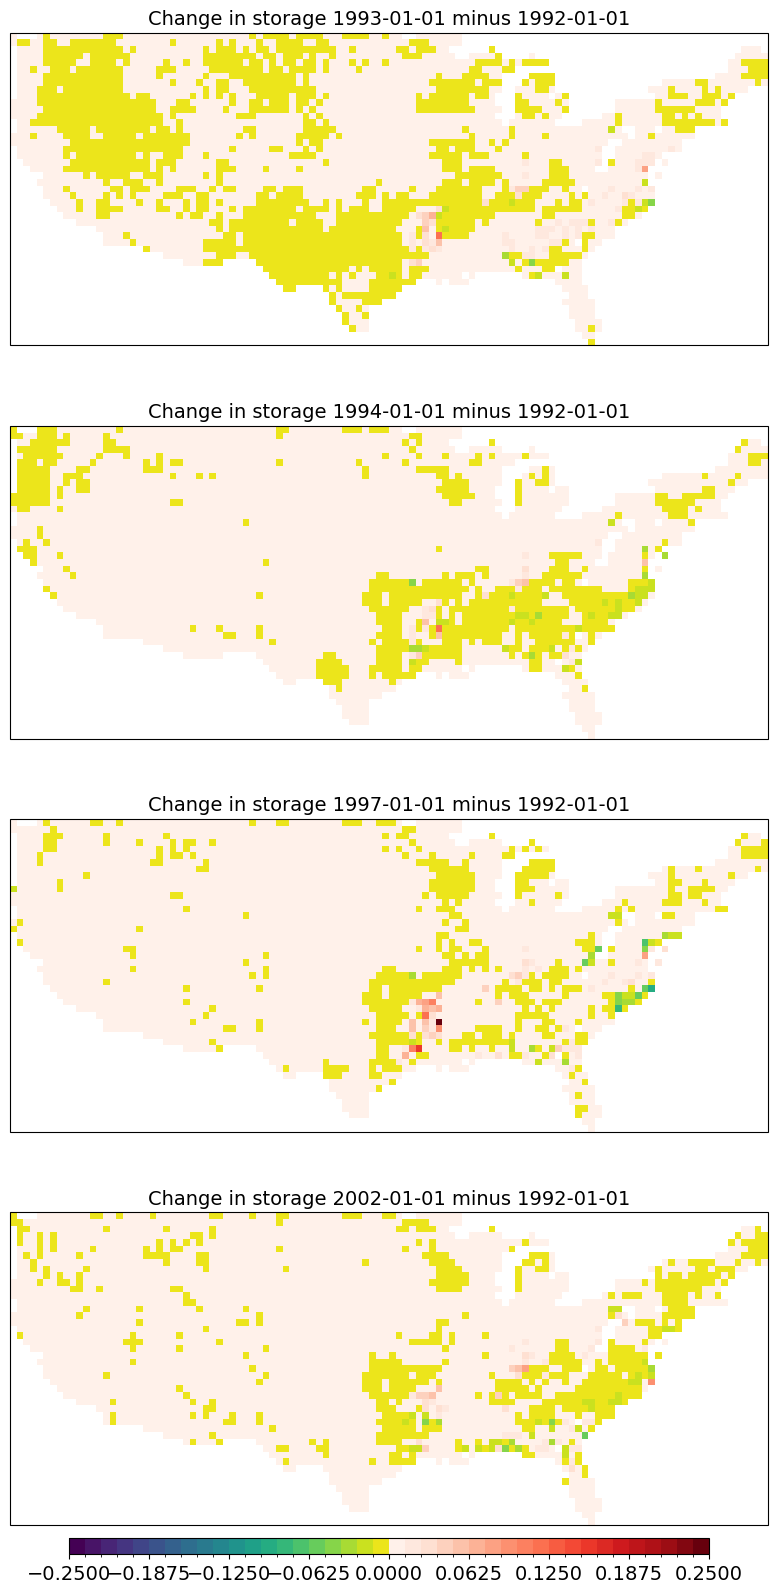

In [7]:
norm = BoundaryNorm(np.linspace(-0.25, 0.25, 41), ncolors = 256*2)

# g m-2 => kg m-2; subtract the start to get storage change
d_stor = (hr['cation'][0::365,:,:,:] - hr['cation'][0,:,:,:]) / 1000
d_stor_alk = sum_to_alkalinity(d_stor)

# plot the change in pore water storage
fig, axes = plt.subplots(4, 1, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (8, 16))
for j,year in enumerate([1,2,5,10]):
    ax = axes[j]
    cf = ax.pcolormesh(lon, lat, d_stor_alk[year,:,:], norm = norm, cmap = combined_cmap)
    ax.set_title(f'Change in storage {start+year}-01-01 minus {start}-01-01')
cax = fig.add_axes([0.1, 0.01, 0.8, 0.01])
plt.colorbar(cf, cax = cax, orientation = 'horizontal')
plt.tight_layout()

# 2. Total CEC and base saturation change

In [16]:
def cec_to_area(cec, bd_col):
    """ meq 100g-1 dry soil * kg soil m-3 soil * 10 = meq m-3 soil"""
    return (cec * 10 * bd_col)

In [17]:
base_cec = (hr['cece_col_1'].resample(time='1Y').first().values + \
            hr['cece_col_2'].resample(time='1Y').first().values + \
            hr['cece_col_3'].resample(time='1Y').first().values + \
            hr['cece_col_4'].resample(time='1Y').first().values + \
            hr['cece_col_5'].resample(time='1Y').first().values)
base_cec = sum_to_depth(
    cec_to_area(base_cec, hr['bd_col'].resample(time='1Y').first().values)
)

total_cec = sum_to_depth(
    cec_to_area(hr['cect_dyn'].resample(time='1Y').first().values, 
                hr['bd_col'].resample(time='1Y').first().values)
)

base_saturation = base_cec / total_cec * 100

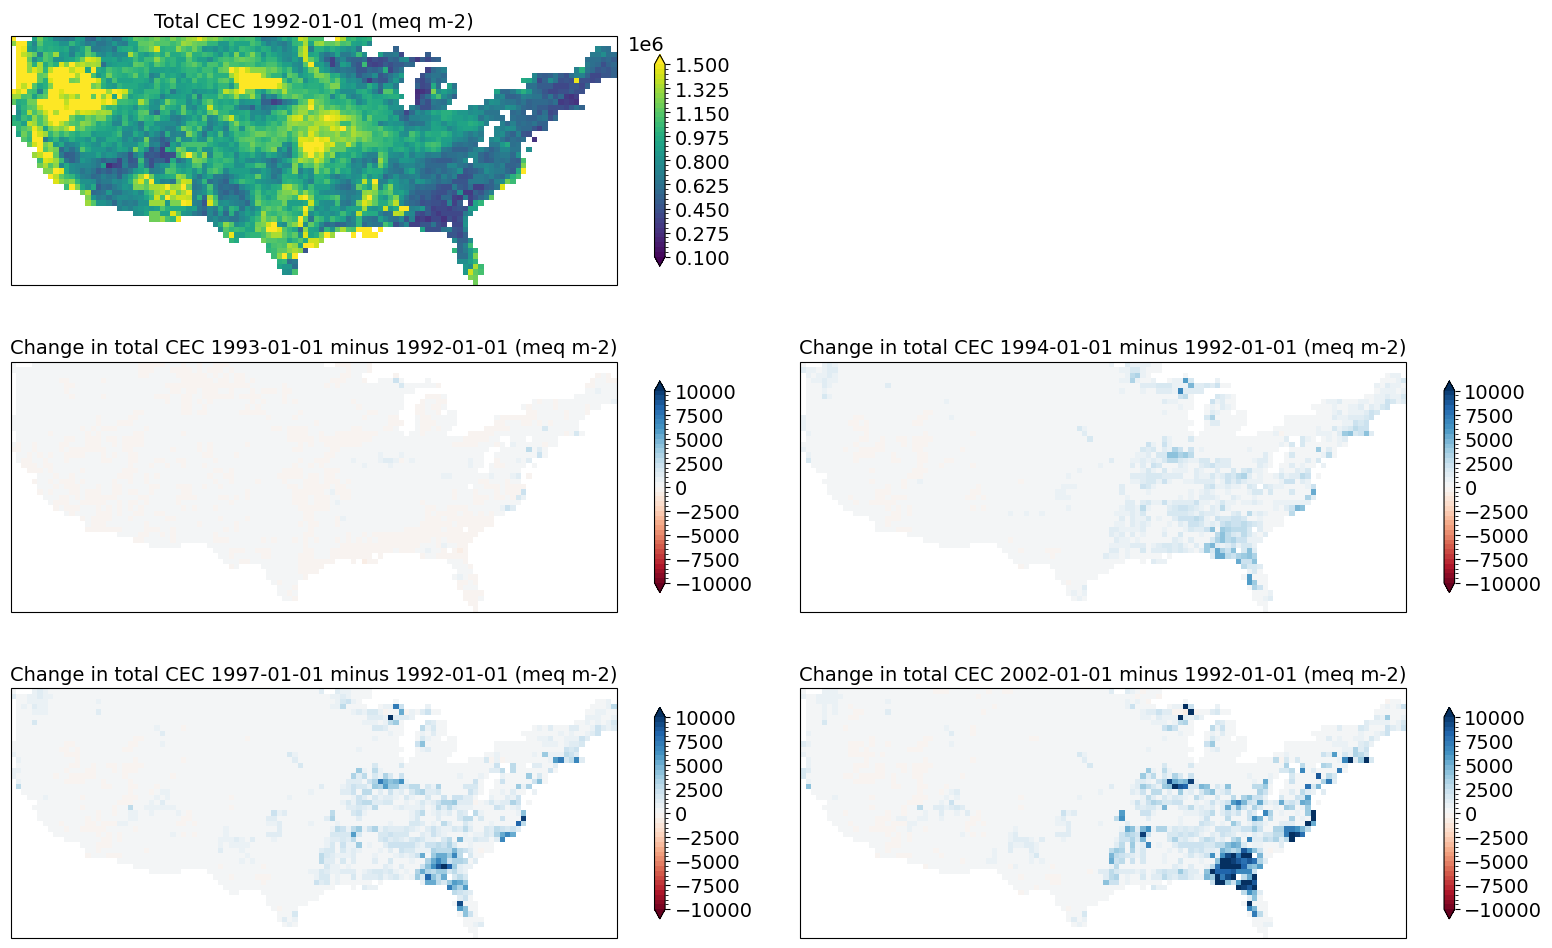

In [42]:
# plot the change in total CEC - this can be expected to be small because pH change is small
fig, axes = plt.subplots(3, 2, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (16, 10))

norm = BoundaryNorm(np.linspace(1e5, 1.5e6, 41), ncolors = 256, extend = 'both')

ax = axes.flat[0]
cf = ax.pcolormesh(lon, lat, total_cec[0,:,:], norm = norm, cmap = 'viridis')
ax.set_title(f'Total CEC {start}-01-01 (meq m-2)')
plt.colorbar(cf, ax = ax, shrink=0.7)

axes.flat[1].axis('off')

norm = BoundaryNorm(np.linspace(-1e4, 1e4, 41), ncolors = 256, extend = 'both')
for j,year in enumerate([1,2,5,10]):
    ax = axes.flat[j+2]
    cf = ax.pcolormesh(lon, lat, total_cec[year,:,:] - total_cec[0,:,:],
                       norm = norm, cmap = 'RdBu')
    ax.set_title(f'Change in total CEC {start+year}-01-01 minus {start}-01-01 (meq m-2)')
    plt.colorbar(cf, ax = ax, shrink = 0.7)
plt.tight_layout()

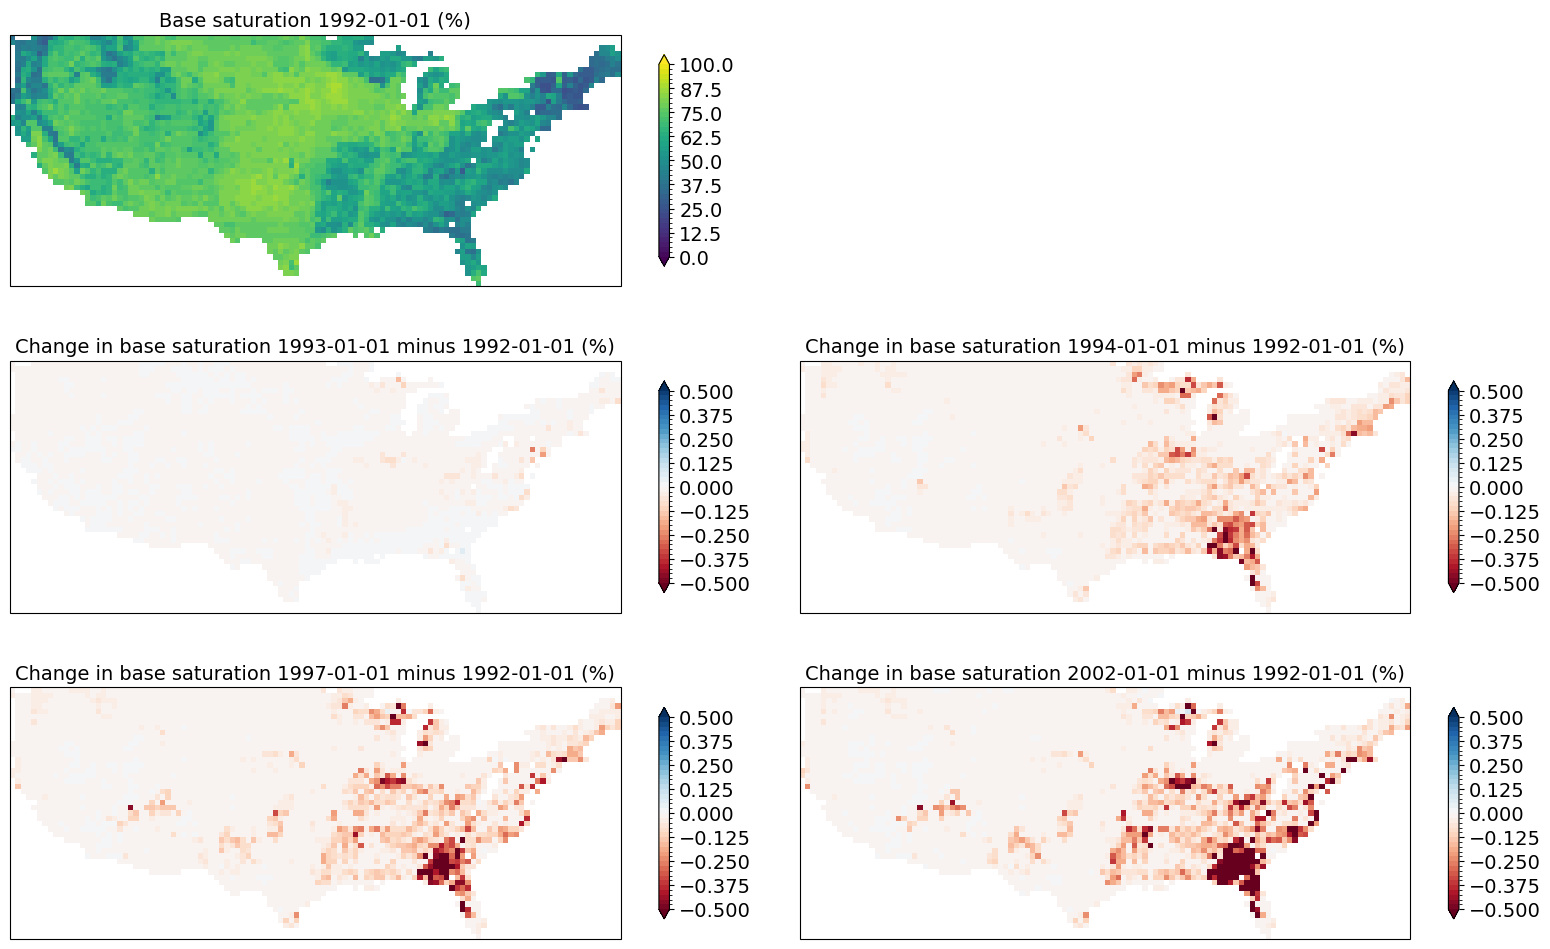

In [46]:
# plot the change in `base saturation
fig, axes = plt.subplots(3, 2, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (16, 10))

norm = BoundaryNorm(np.linspace(0, 100, 41), ncolors = 256, extend = 'both')

ax = axes.flat[0]
cf = ax.pcolormesh(lon, lat, base_saturation[0,:,:], norm = norm, cmap = 'viridis')
ax.set_title(f'Base saturation {start}-01-01 (%)')
plt.colorbar(cf, ax = ax, shrink=0.7)

axes.flat[1].axis('off')

norm = BoundaryNorm(np.linspace(-0.5, 0.5, 41), ncolors = 256, extend = 'both')
for j,year in enumerate([1,2,5,10]):
    ax = axes.flat[j+2]
    cf = ax.pcolormesh(lon, lat, base_saturation[year,:,:] - base_saturation[0,:,:],
                       norm = norm, cmap = 'RdBu')
    ax.set_title(f'Change in base saturation {start+year}-01-01 minus {start}-01-01 (%)')
    plt.colorbar(cf, ax = ax, shrink = 0.7)
plt.tight_layout()

# 4. CDR efficiency

Defined as 

(Cumulative Infiltration + Leach - Background)/(Cumulative Dissolved)

In [51]:
efficiency = - (infl_alk + leach_alk - background_alk) / primary_alk

/tmp/ipykernel_168005/1127384207.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


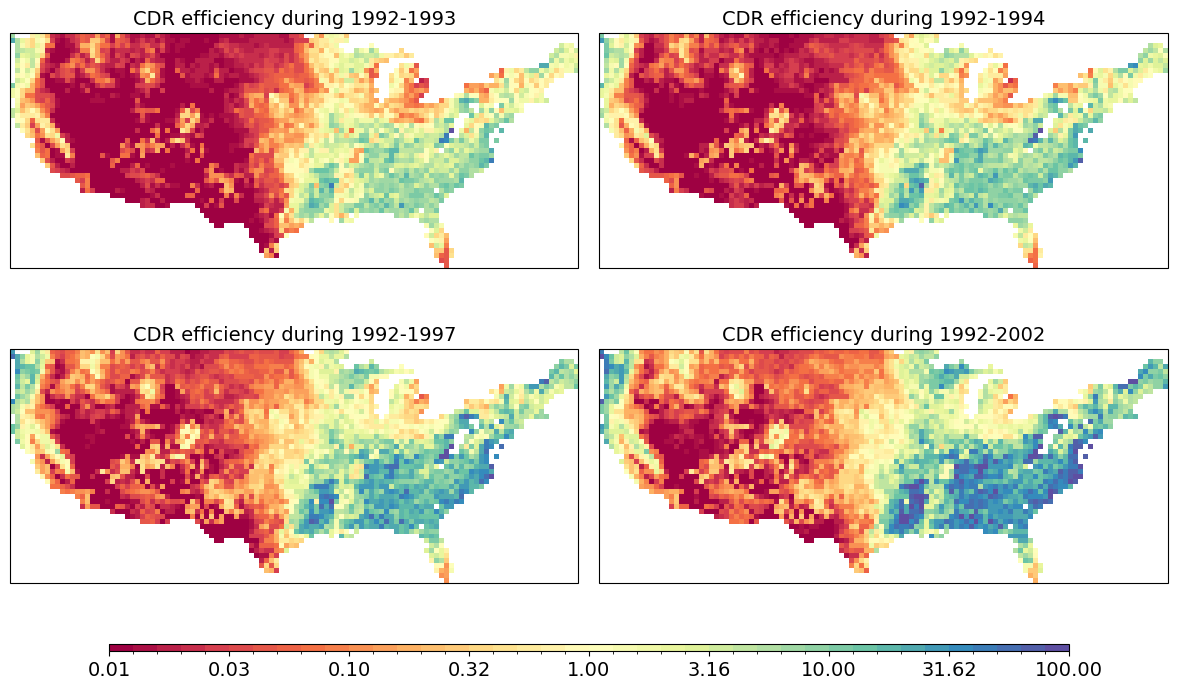

In [62]:
norm = BoundaryNorm(np.power(10, np.linspace(-2, 2, 41)), ncolors = 256)

# plot the change in pore water storage
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize = (12, 7))
for j,year in enumerate([1,2,5,10]):
    ax = axes.flat[j]
    cf = ax.pcolormesh(lon, lat, efficiency[year,:,:], norm = norm, cmap = 'Spectral')
    ax.set_title(f'CDR efficiency during {start}-{start+year}')
cax = fig.add_axes([0.1, 0.01, 0.8, 0.01])
plt.colorbar(cf, cax = cax, orientation = 'horizontal')
plt.tight_layout()